In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder



In [3]:
from imblearn.over_sampling import SMOTE  # Install with: pip install imbalanced-learn
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


In [5]:
# Load the dataset 
df = pd.read_csv('bank_full.csv', delimiter=';')
df.shape

(45211, 17)

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Data Cleaning and Explaratory Data Analysis(EDA)

In [14]:
# Checking for missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [16]:
# Checking for duplicate values
df.duplicated().sum()

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [20]:
# Summary of descriptive statistics for numerical columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [22]:
# Summary of descriptive statistics for categorical columns
df.describe(include= "O").T


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


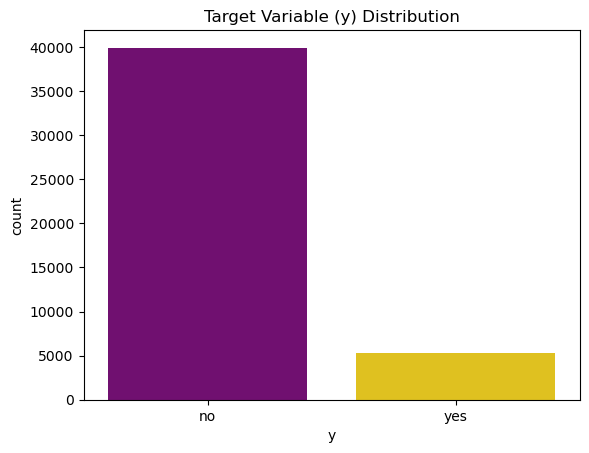

In [24]:
# Target Variable Distribution
custom_palette = {"yes": "#FFD700", "no": "#800080"}
sns.countplot(x='y', data=df, palette=custom_palette)
plt.title("Target Variable (y) Distribution")
plt.show()

#### Numerical Variables

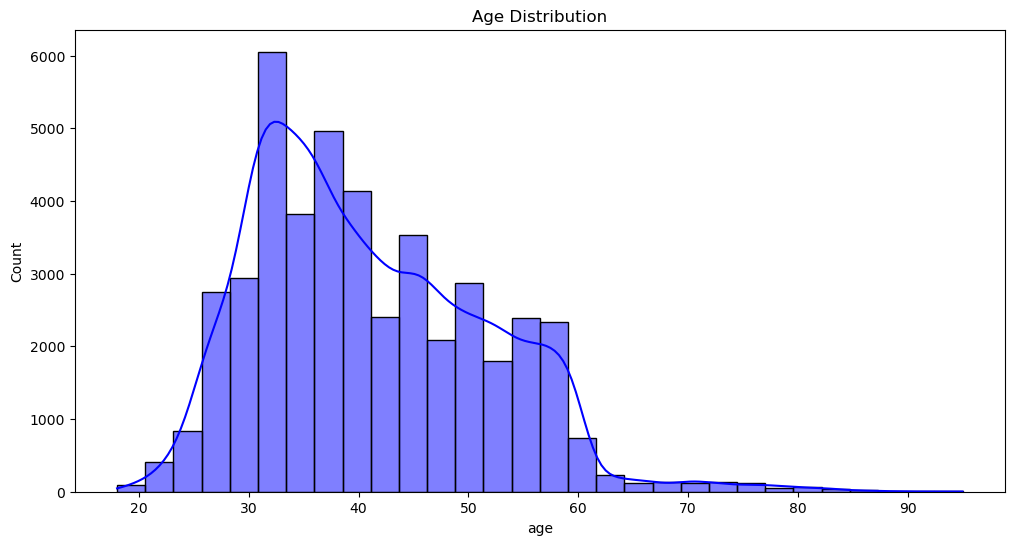

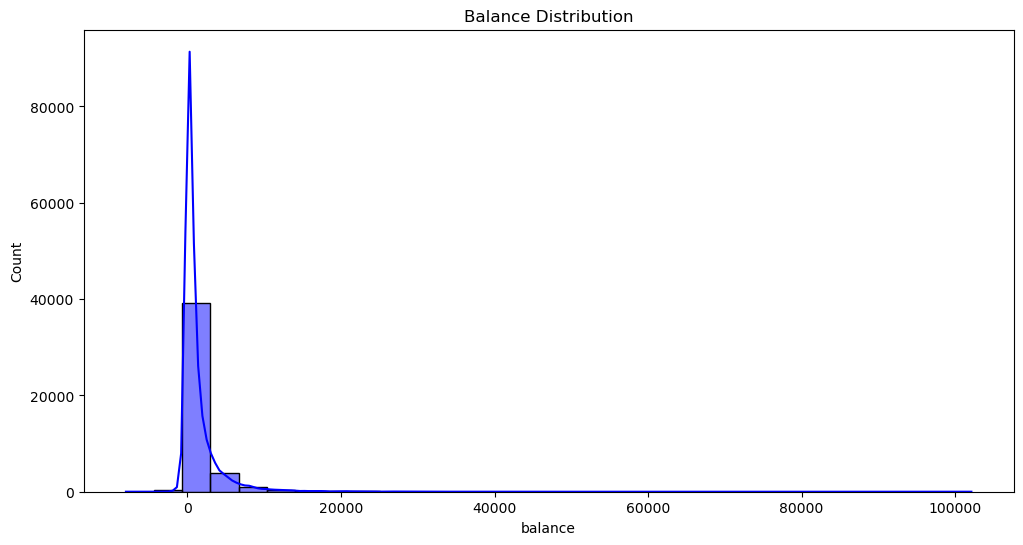

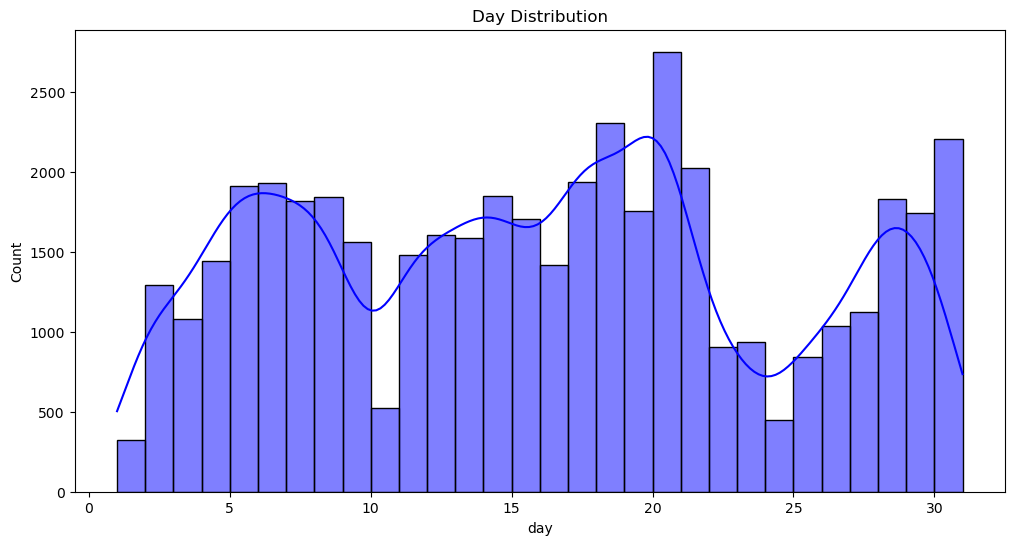

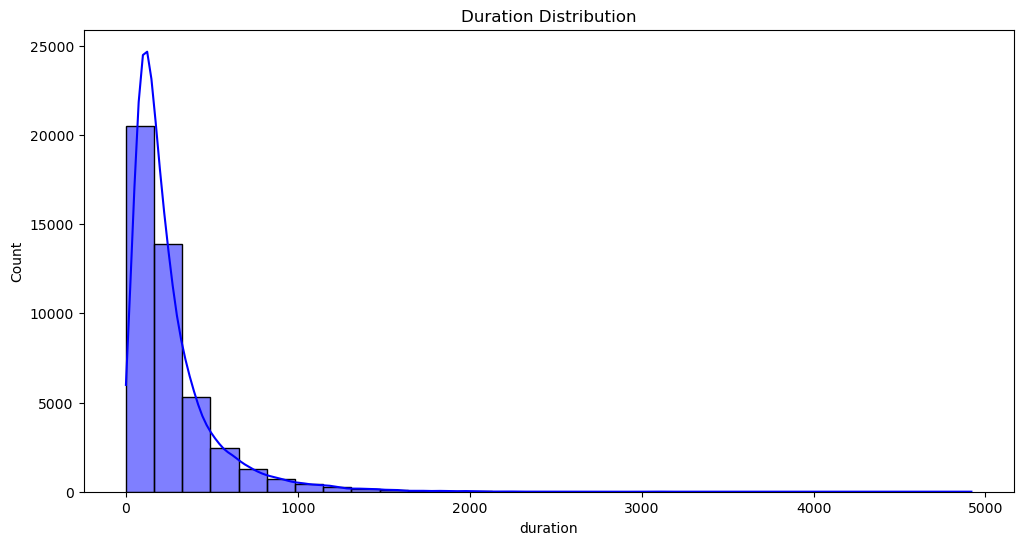

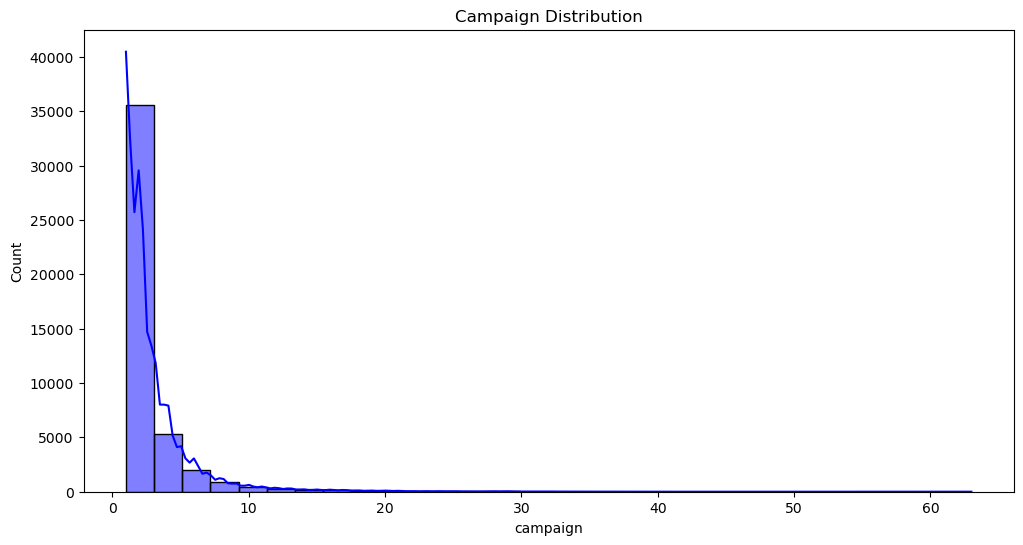

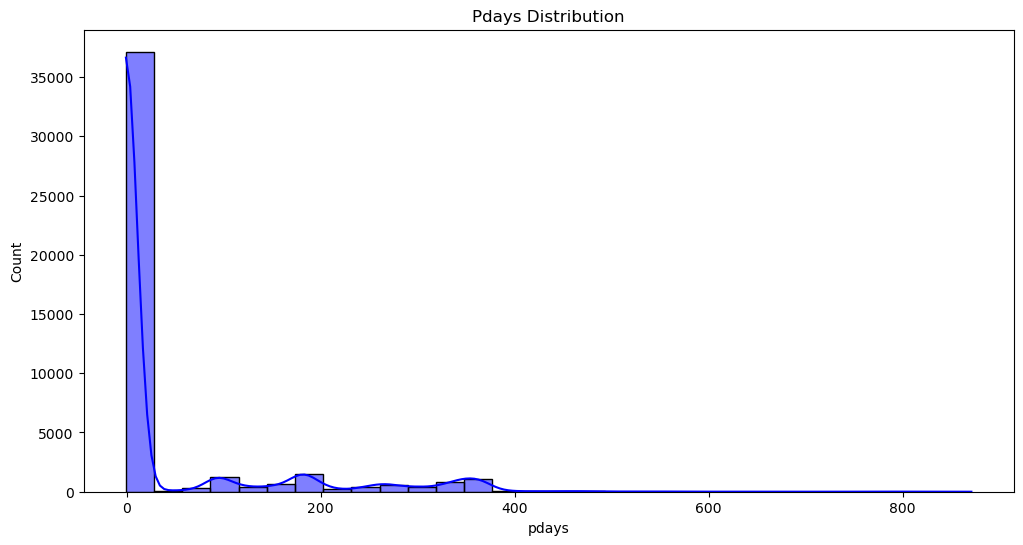

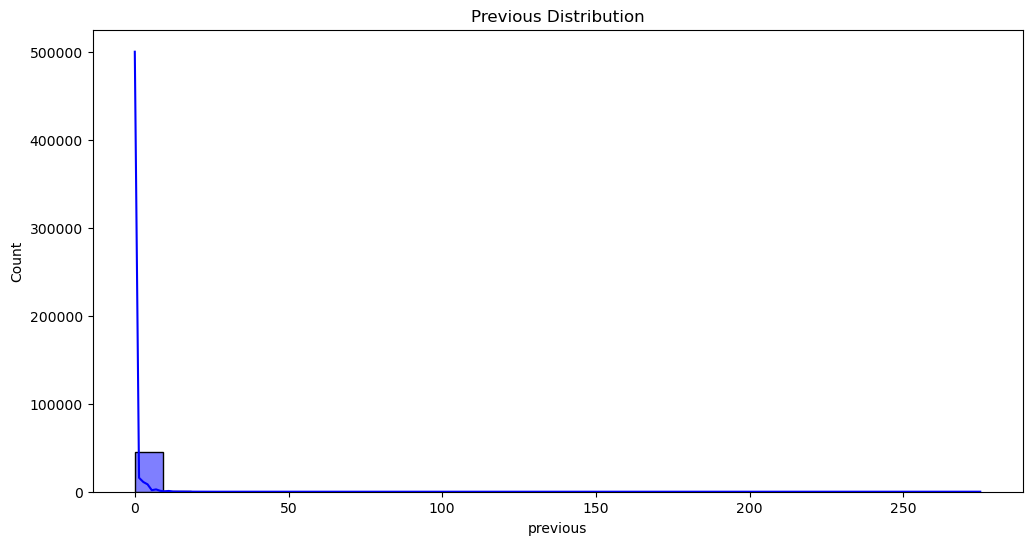

In [27]:
# Numerical_variables distributions
numerical_variables = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

for feature in numerical_variables:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[feature], kde=True, color='blue', bins=30)
    plt.title(f"{feature.capitalize()} Distribution")
    plt.show()


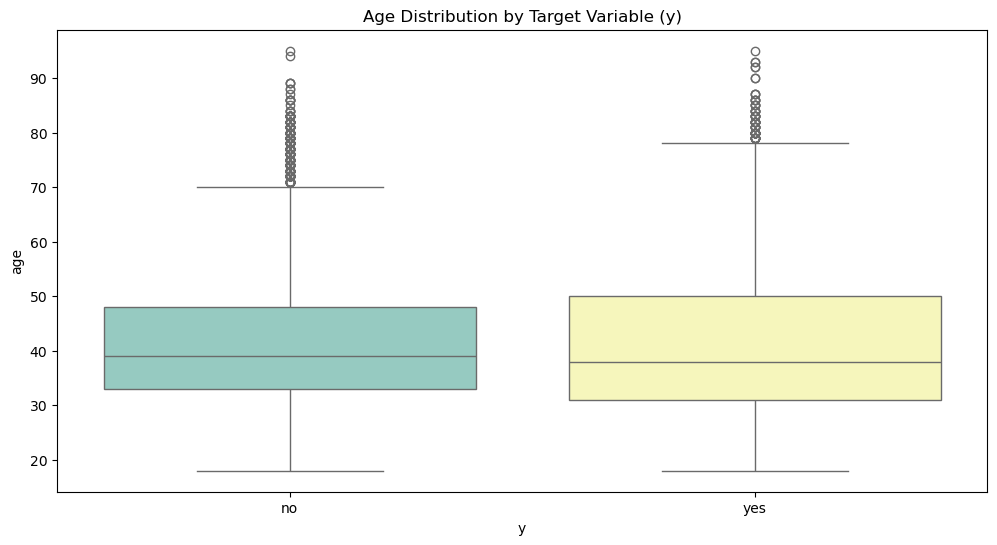

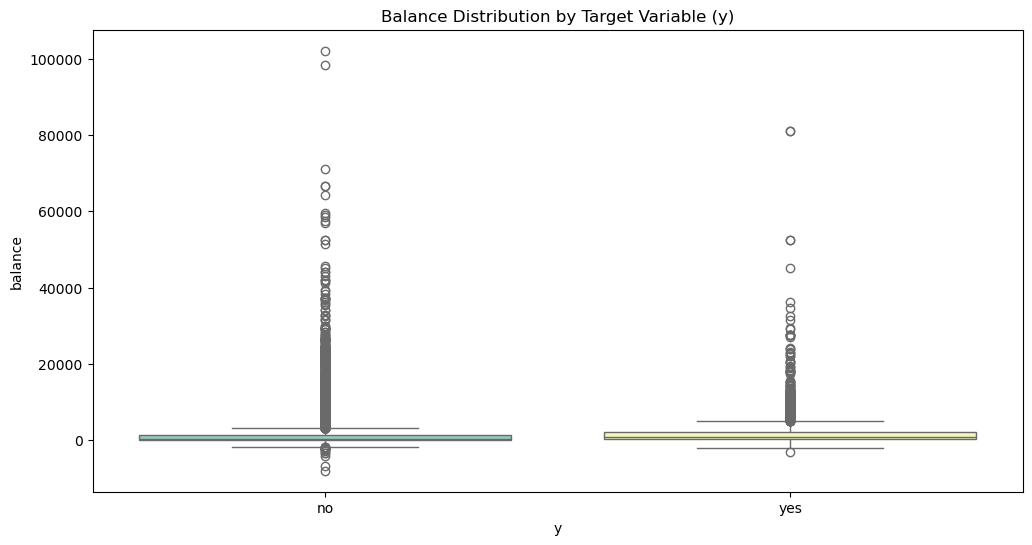

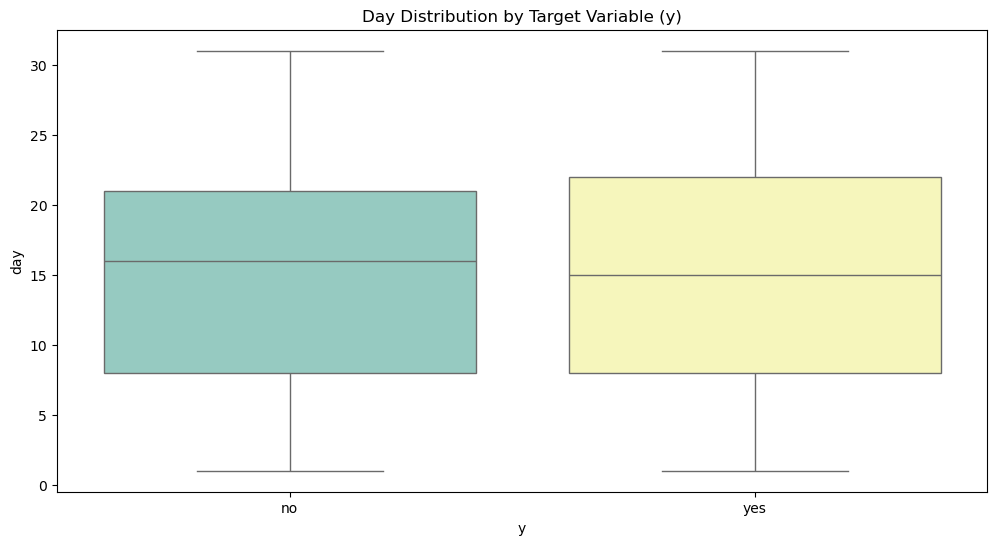

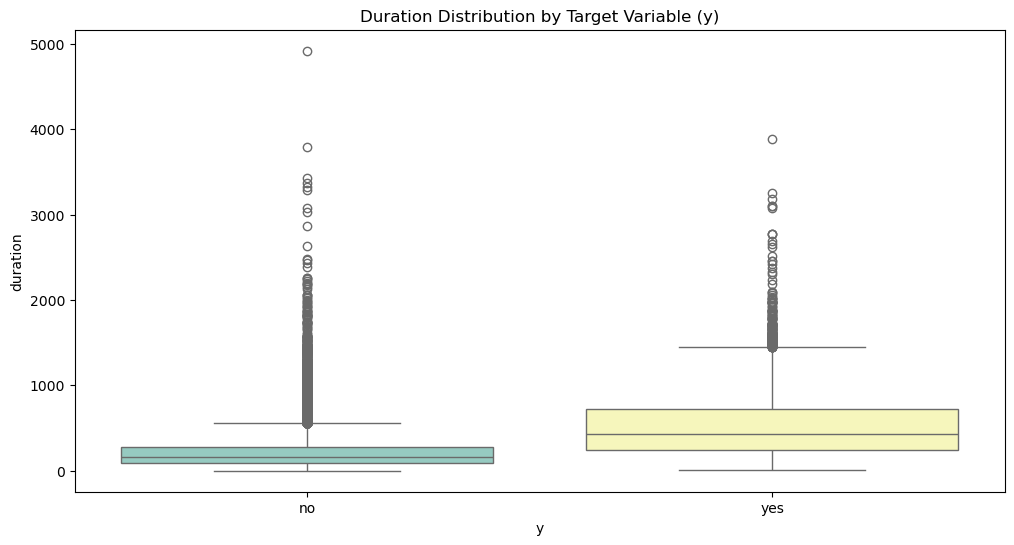

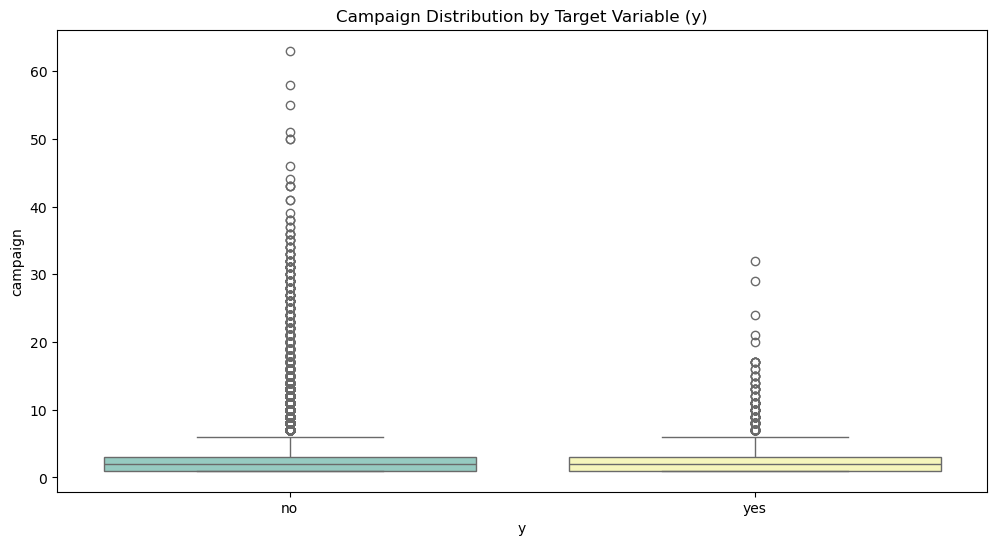

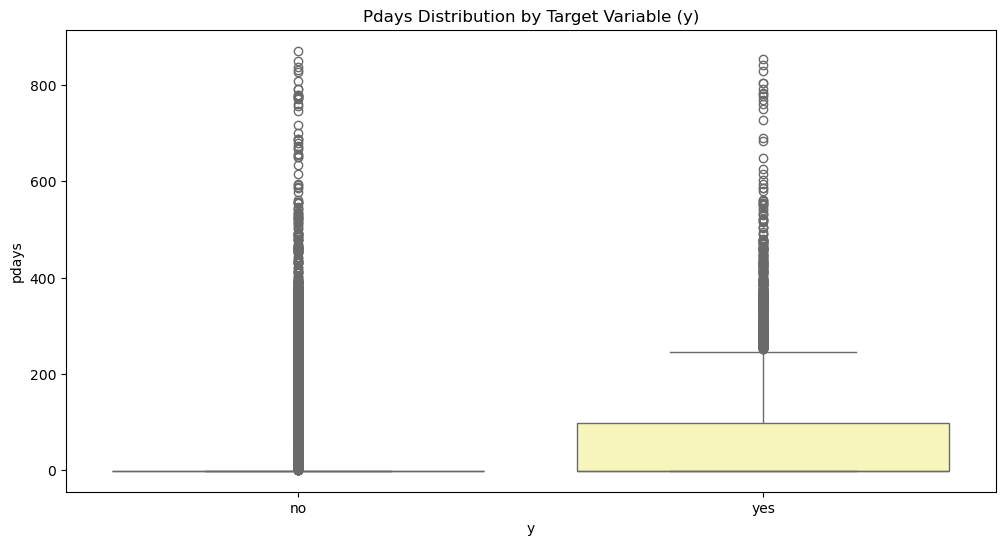

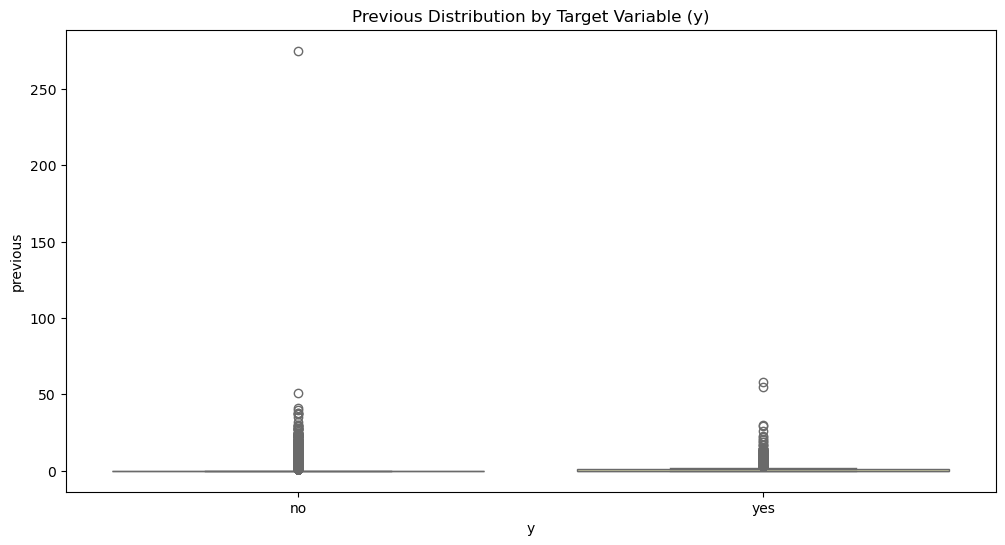

In [29]:
# Numerical_variables vs y
for feature in numerical_variables:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='y', y=feature, data=df, palette='Set3')
    plt.title(f"{feature.capitalize()} Distribution by Target Variable (y)")
    plt.show()


#### Categorical Variables

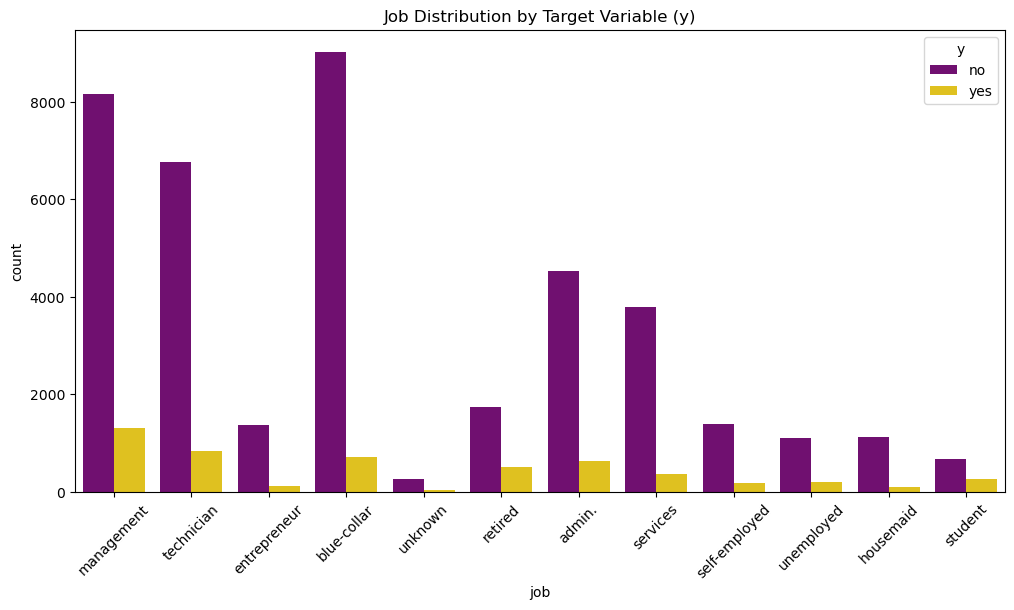

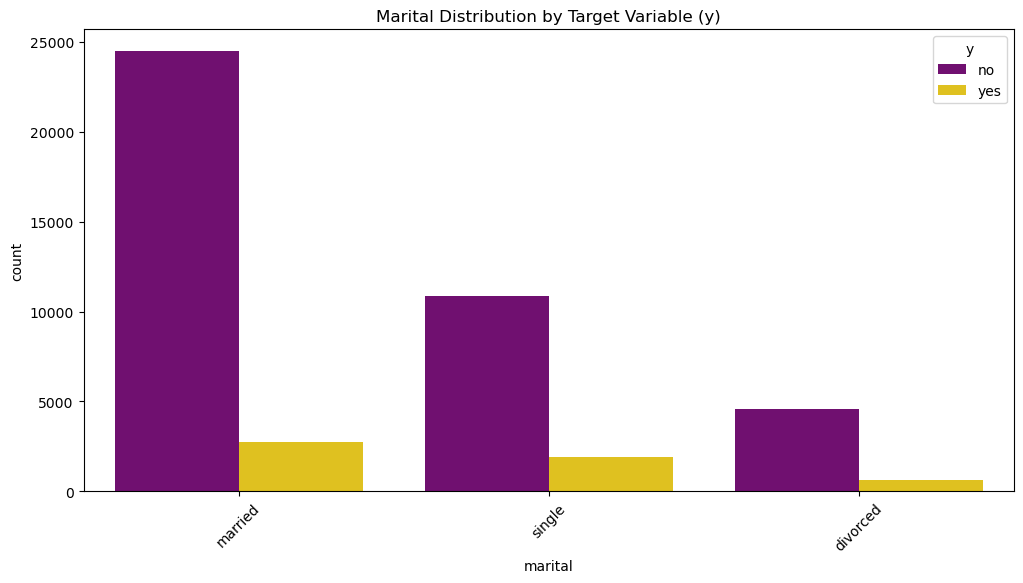

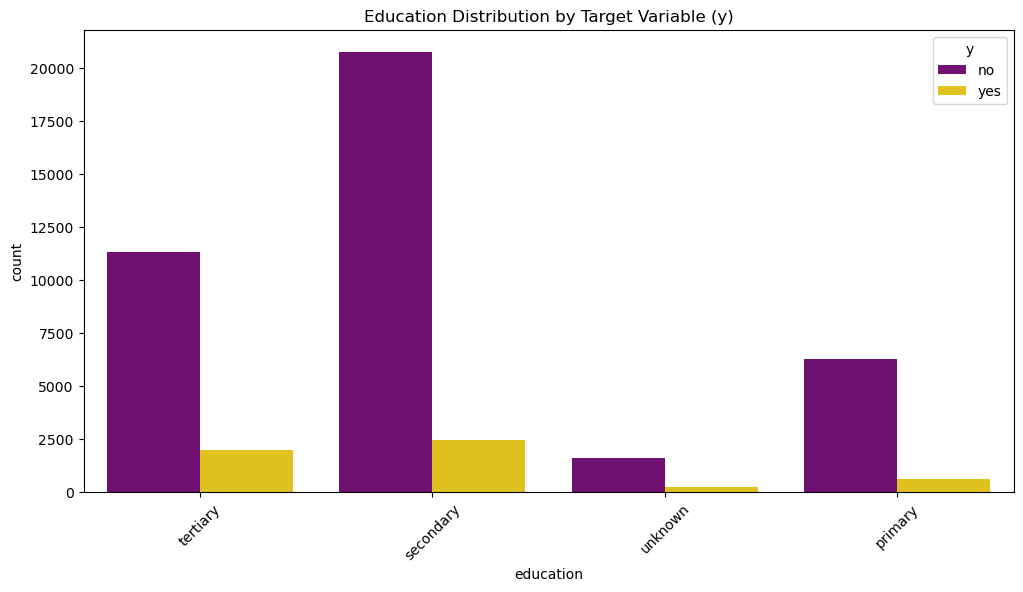

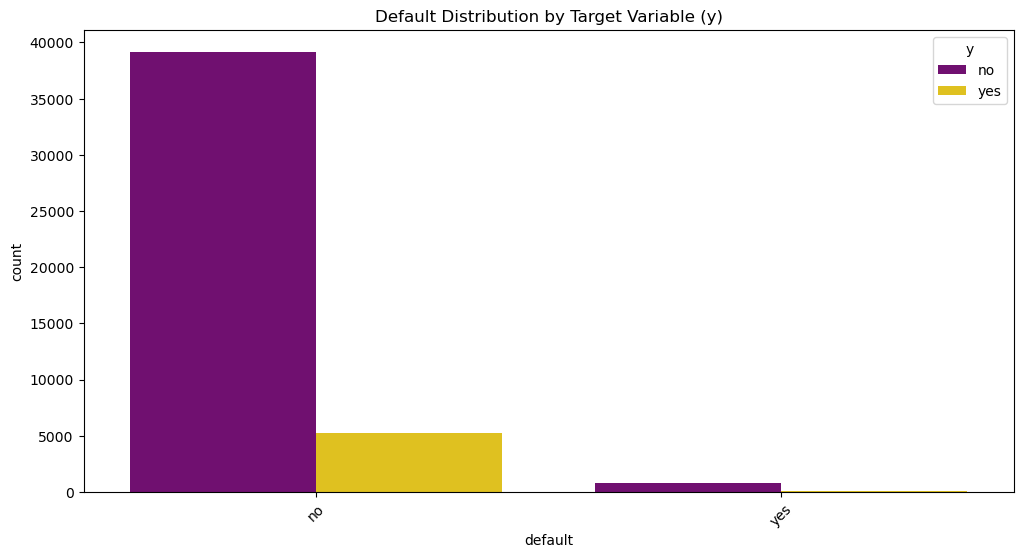

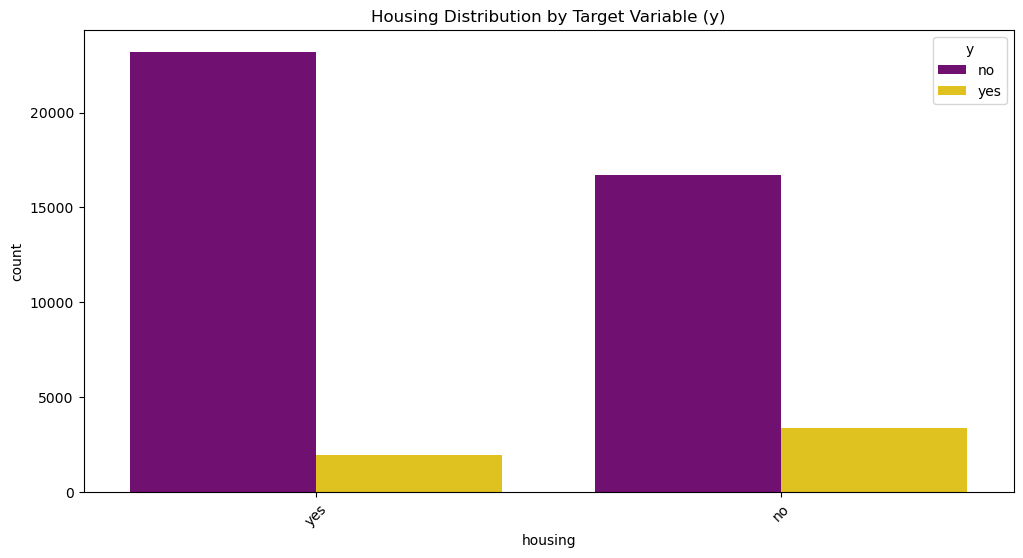

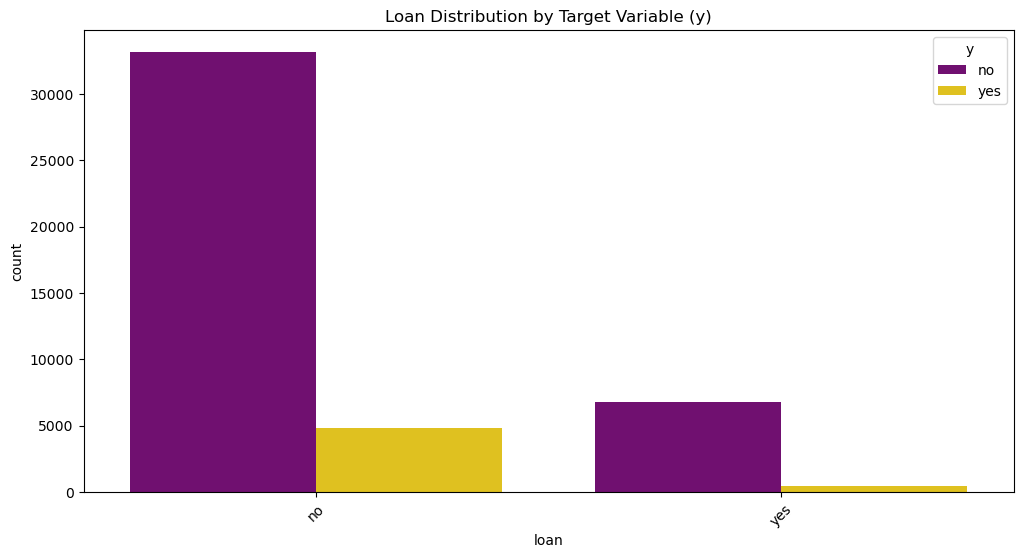

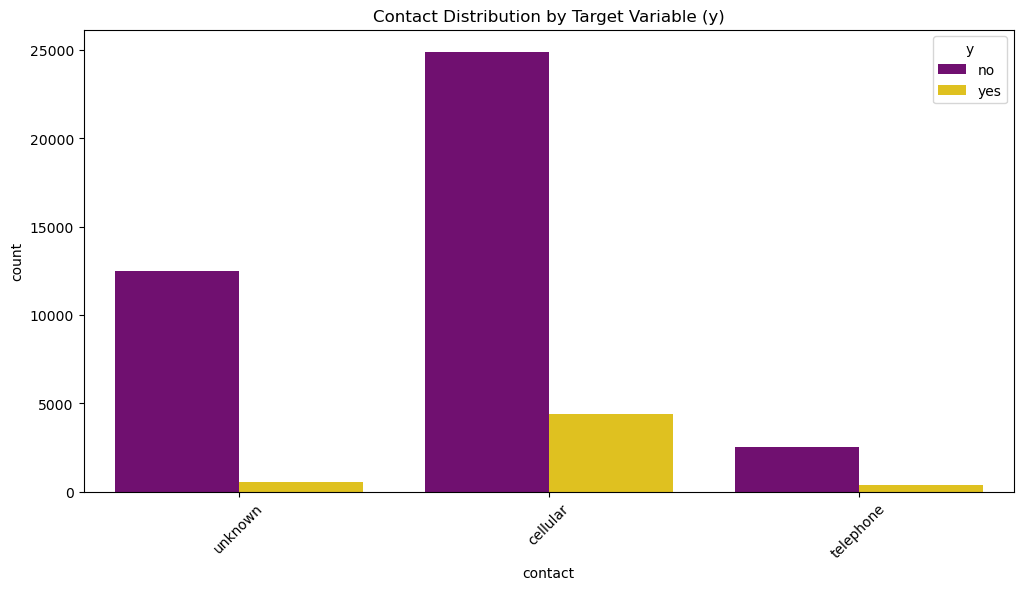

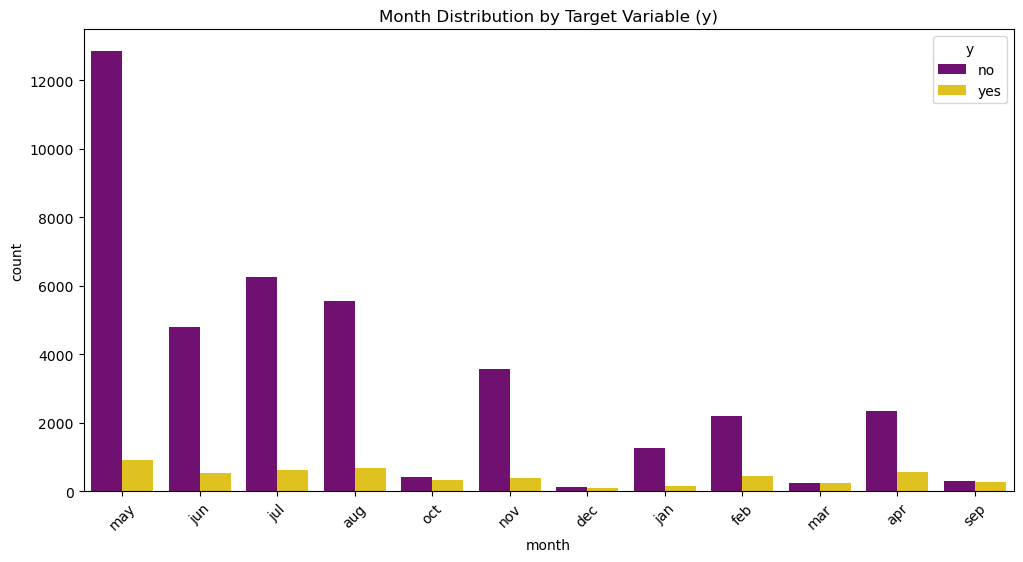

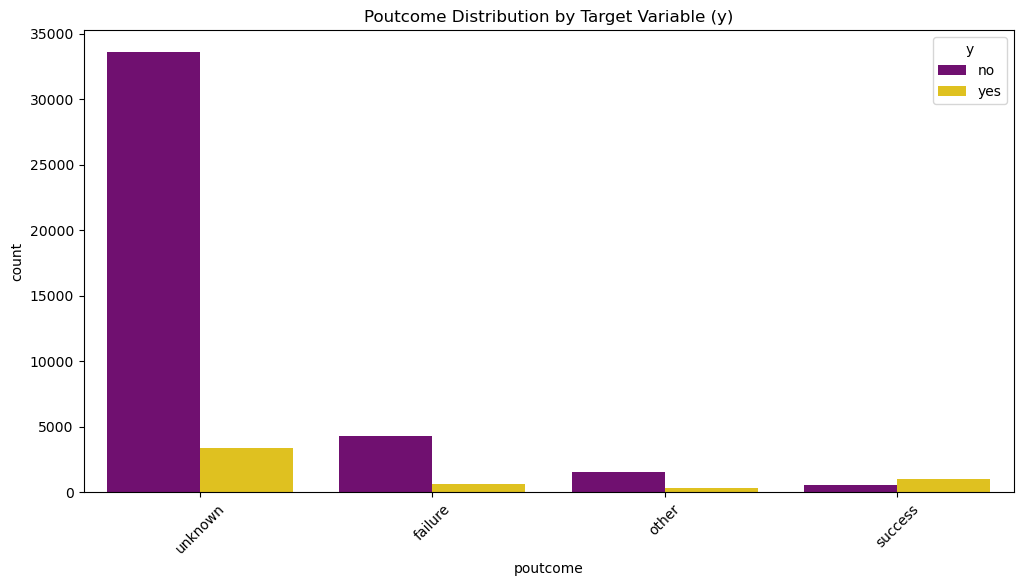

In [32]:
# Categorical_variables
categorical_variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Define a custom palette (e.g., using hex color codes)
custom_palette = {"yes": "#FFD700", "no": "#800080"}

for feature in categorical_variables:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=feature, hue='y', data=df, palette=custom_palette)
    plt.title(f"{feature.capitalize()} Distribution by Target Variable (y)")
    plt.xticks(rotation=45)
    plt.show()


<Figure size 1200x800 with 0 Axes>

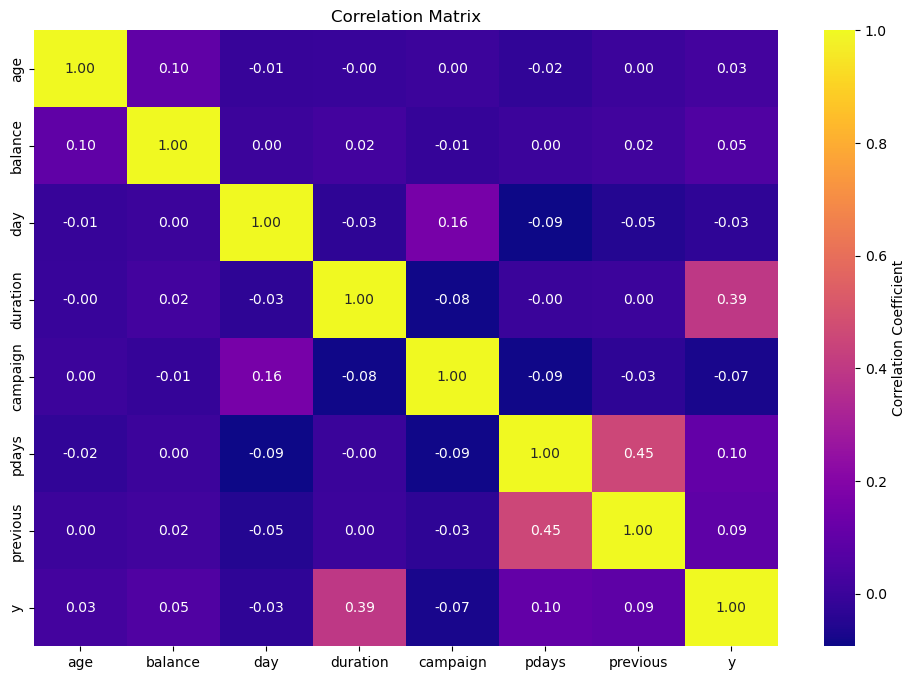

In [42]:
fig = plt.figure(figsize=(12,8))
df['y'] = LabelEncoder().fit_transform(df['y'])

# Selecting only numerical columns for the correlation matrix
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix
corr_matrix = df[numerical_columns].corr()

# Plot the correlation matrix
fig = plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Matrix")
plt.show()


### ***Correlation between the variables and the target variable y***
**duration (0.39):**
The strongest positive correlation with y. This indicates that clients who had longer last contact durations are significantly more likely to subscribe to a term deposit. This feature is critical and should be a key focus for predictive modeling.

**pdays (0.10):**
A weak positive correlation with y. This suggests that clients who were contacted more recently in previous campaigns are slightly more likely to subscribe, but the relationship is not very strong.

**previous (0.09):**
A weak positive correlation with y. This implies that clients who were contacted more times in past campaigns have a slightly higher chance of subscribing to the term deposit.

**balance (0.05):**
An almost negligible positive correlation with y. This suggests that the client’s average yearly balance does not play a significant role in determining whether they subscribe to a term deposit.

**campaign (-0.07):**
A weak negative correlation with y. This indicates that clients contacted multiple times during the current campaign are slightly less likely to subscribe, possibly hinting at diminishing returns or even negative effects of excessive follow-ups.

**day (0.03):**
No meaningful correlation with y. The specific day of the month when the last contact was made does not seem to influence whether a client subscribes.

**age (0.03):**
A very weak positive correlation with y. This suggests that age has minimal influence on the likelihood of subscribing.


*To summarise: duration is by far the most influential variable in this dataset for predicting the target variable y. It indicates that the success of the marketing campaign is closely tied to the duration of client interactions.*

In [18]:
# Create a copy of the dataset for encoding
df_encoded = df.copy()

# List of columns to be encoded
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

# Apply Label Encoding
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])  # Apply transformation to df_encoded
    label_encoders[col] = le  # Save encoder for future use

df_encoded = df_encoded.drop(columns=['y_binary'], errors='ignore')

# Displaying the first few rows of the encoded dataset
df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


#### Data Preparation and Encoding

In [60]:
# List of columns to be encoded
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

# Create OrdinalEncoder and fit on the training data
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

# Define features and target
X = df.drop(columns=['y'])  # Drop target column
y = df['y']  # Target column

#### Splitting the Dataset

In [66]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Further split train set into train and validation
X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Baseline Accuracy
acc_baseline = y_train_new.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.88


#### Handling Class Imbalance with SMOTE

In [69]:
# Apply SMOTE to address class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_new, y_train_new)

#### Decision Tree Classifier and Hyperparameter Tuning

In [72]:
# Define Decision Tree model
decision_tree = DecisionTreeClassifier(class_weight='balanced', criterion='entropy', random_state=42)

# Create a pipeline with SMOTE and the Decision Tree
classifier = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),  # Apply OrdinalEncoder separately
    ('model', decision_tree)
])

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(classifier, param_grid, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_res, y_train_res)

# Best parameters from GridSearchCV
print("Best parameters from GridSearchCV:", grid_search.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters from GridSearchCV: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


#### Evaluating the Decision Tree Classifier

In [75]:
# Evaluate the tuned decision tree on the test set
y_pred = grid_search.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Accuracy on the test set
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Set: {acc}")

# Evaluate on Validation Set
y_val_pred = grid_search.predict(X_val)
print("Validation Set Classification Report:")
print(classification_report(y_val, y_val_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93      9950
         1.0       0.47      0.63      0.54      1353

    accuracy                           0.87     11303
   macro avg       0.71      0.77      0.73     11303
weighted avg       0.89      0.87      0.88     11303

Accuracy on Test Set: 0.8718924179421392
Validation Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.93      6005
         1.0       0.46      0.62      0.53       777

    accuracy                           0.87      6782
   macro avg       0.70      0.76      0.73      6782
weighted avg       0.89      0.87      0.88      6782



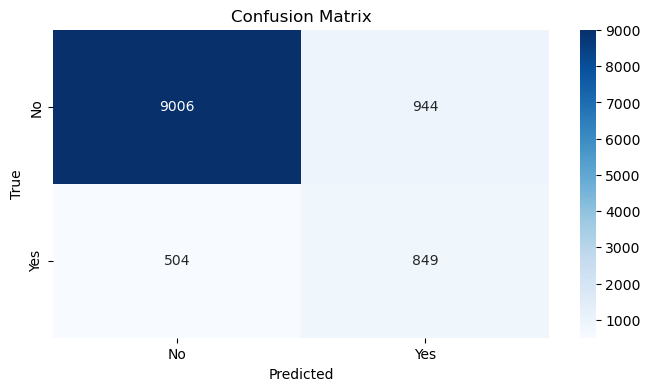

In [79]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()